Saving Custom_Crops_yield_Historical_Dataset.csv to Custom_Crops_yield_Historical_Dataset.csv
✅ Data loaded: (50765, 20)


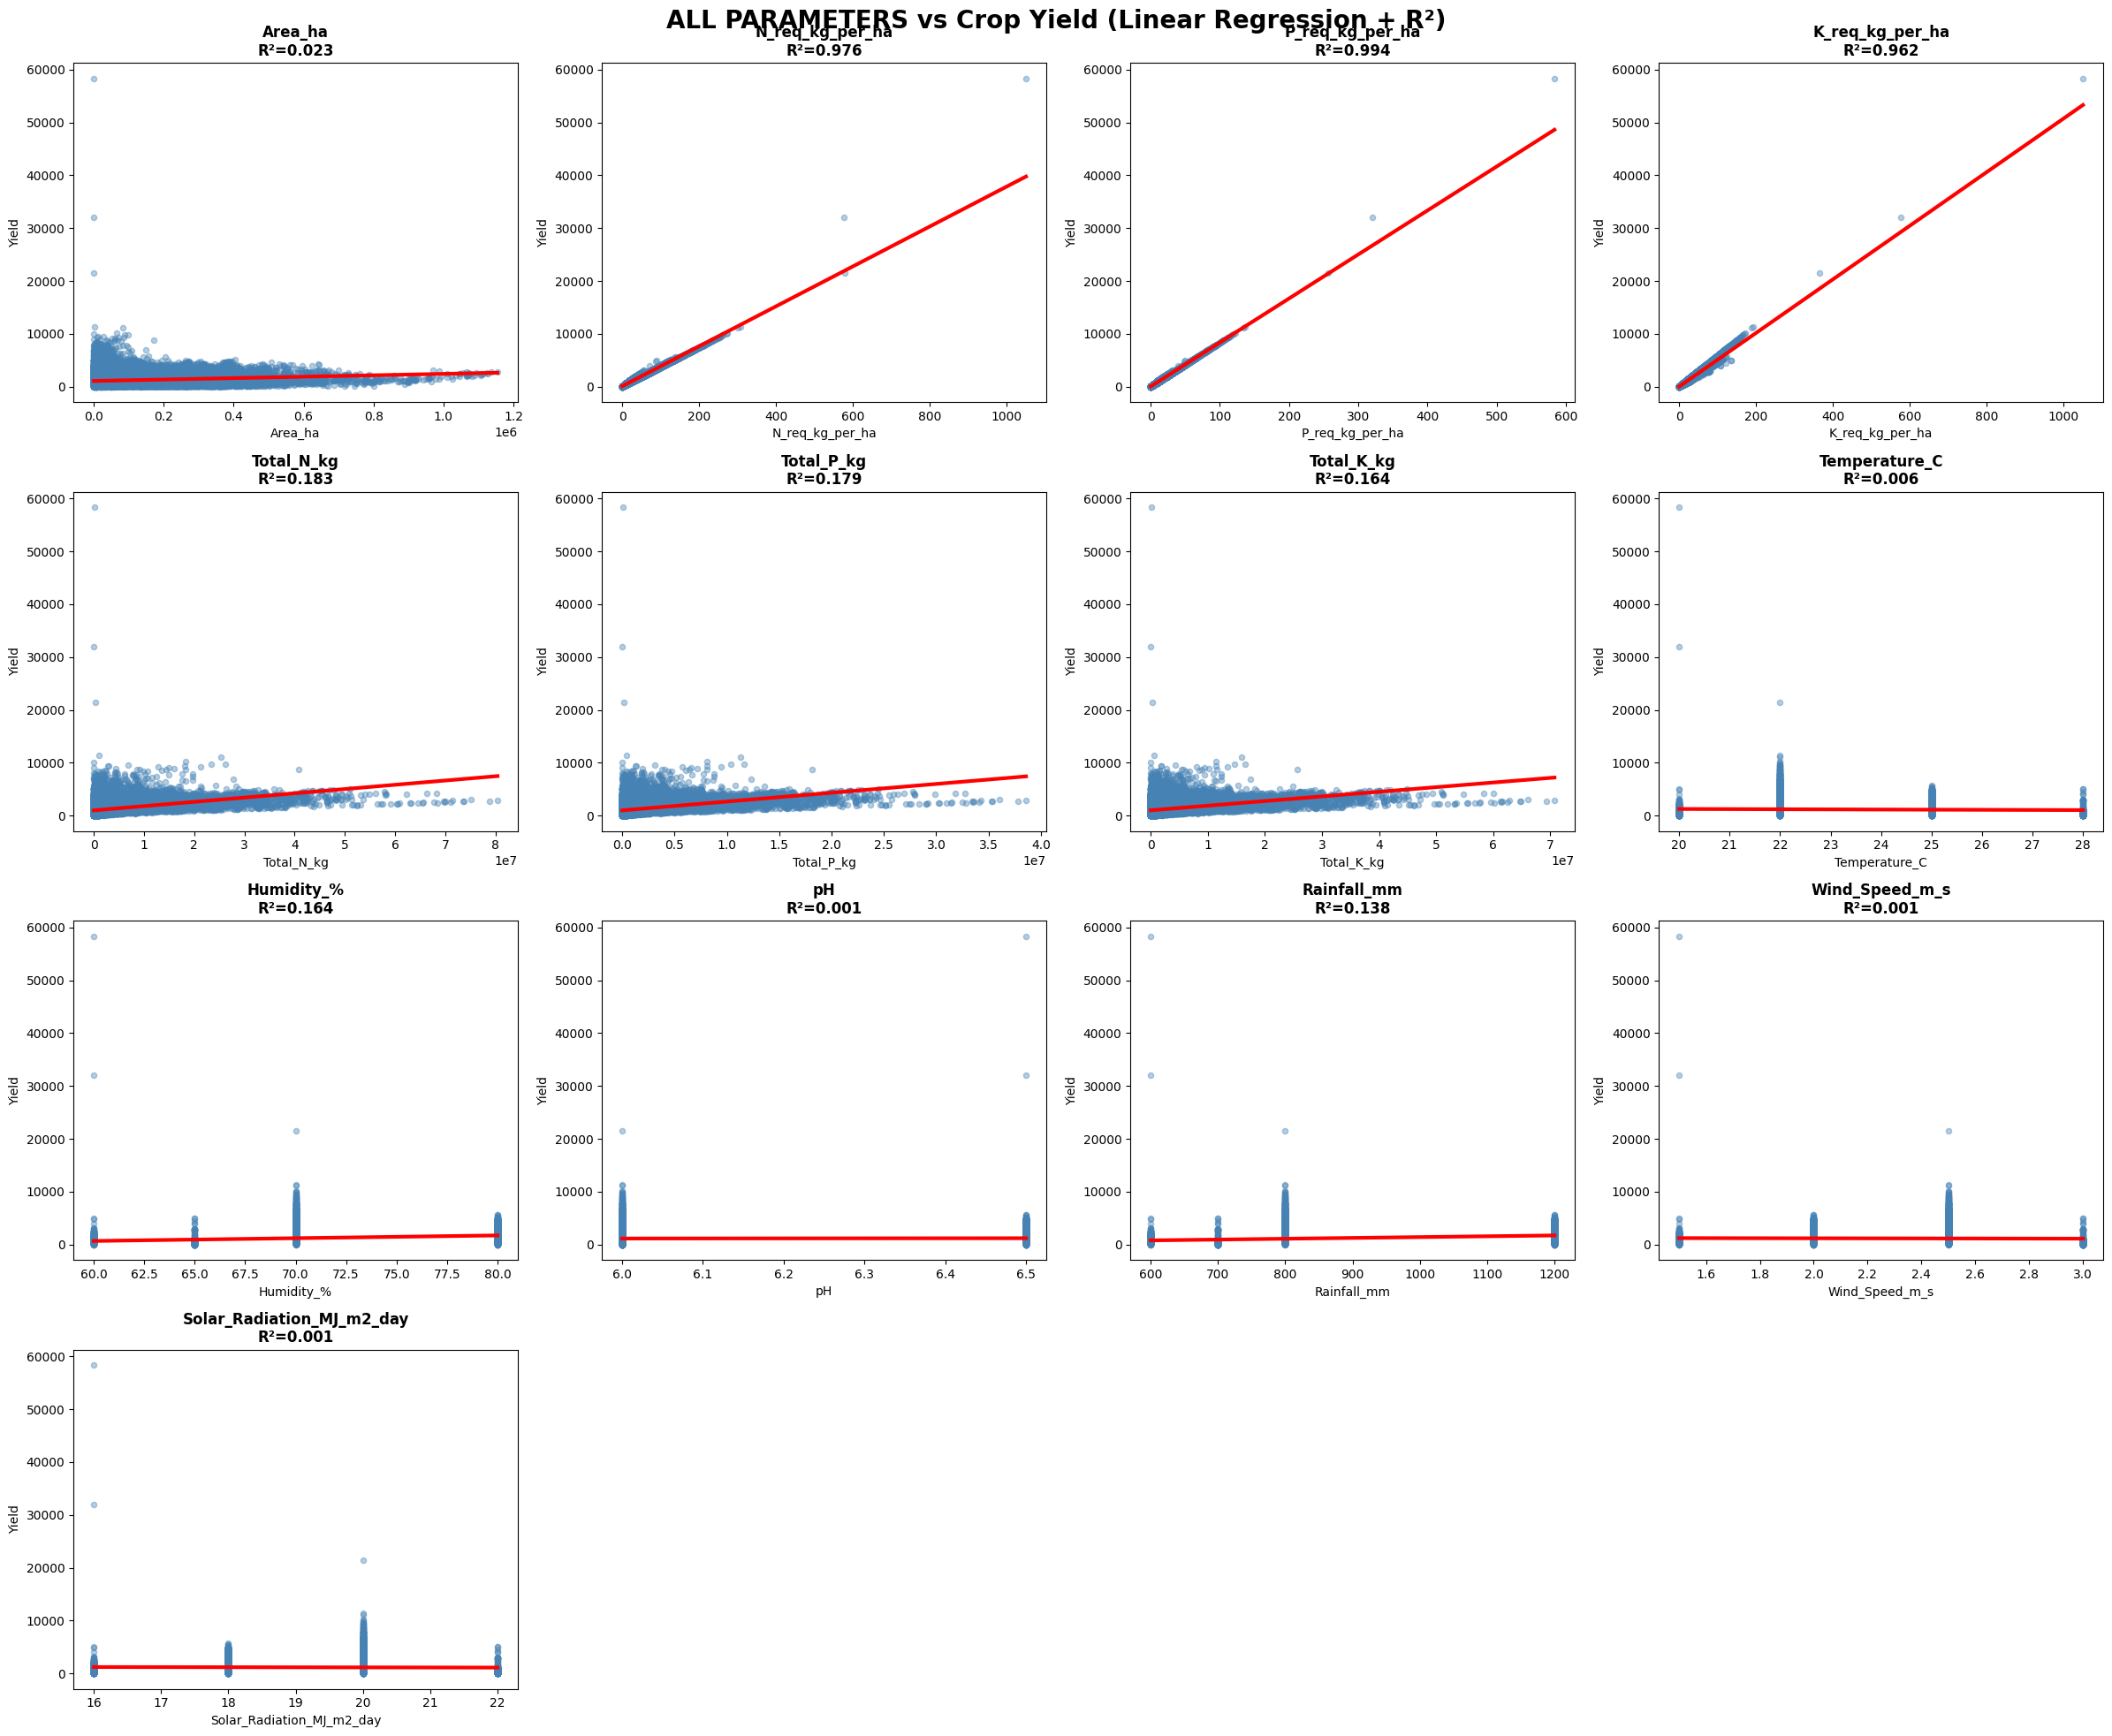


TOP 5 PARAMETERS BY R² SCORE:
          Parameter  R2_Score
2   P_req_kg_per_ha    0.9939
1   N_req_kg_per_ha    0.9763
3   K_req_kg_per_ha    0.9621
4        Total_N_kg    0.1830
5        Total_P_kg    0.1786
6        Total_K_kg    0.1640
8        Humidity_%    0.1639
10      Rainfall_mm    0.1378
0           Area_ha    0.0227
7     Temperature_C    0.0056


In [1]:
# Complete code - upload + all graphs side by side
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# 1. UPLOAD & LOAD DATA
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])
print("✅ Data loaded:", df.shape)

# 2. ALL PARAMETERS vs YIELD - SIDE BY SIDE
target = 'Yield_kg_per_ha'
features = ['Area_ha', 'N_req_kg_per_ha', 'P_req_kg_per_ha', 'K_req_kg_per_ha',
           'Total_N_kg', 'Total_P_kg', 'Total_K_kg', 'Temperature_C',
           'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day']

# Create 4x4 grid (16 plots, last 3 empty)
fig, axes = plt.subplots(4, 4, figsize=(24, 20))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]

    # Linear regression line
    X = df[[feature]].values
    y = df[target].values
    model = LinearRegression().fit(X, y)
    y_pred = model.predict(X)

    r2 = r2_score(y, y_pred)

    # Scatter + regression line
    ax.scatter(df[feature], df[target], alpha=0.4, s=20, color='steelblue')
    sort_idx = np.argsort(df[feature])
    ax.plot(df[feature].iloc[sort_idx], y_pred[sort_idx], 'red', linewidth=3)

    ax.set_title(f'{feature}\nR²={r2:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Yield')

# Hide empty subplots
for i in range(len(features), 16):
    fig.delaxes(axes[i])

plt.suptitle('ALL PARAMETERS vs Crop Yield (Linear Regression + R²)', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. CONCLUSION - Best predictors (highest R²)
print("\n" + "="*60)
print("TOP 5 PARAMETERS BY R² SCORE:")
print("="*60)

r2_scores = []
for feature in features:
    X = df[[feature]].values
    y = df[target].values
    r2 = r2_score(y, LinearRegression().fit(X, y).predict(X))
    r2_scores.append((feature, r2))

r2_df = pd.DataFrame(r2_scores, columns=['Parameter', 'R2_Score']).sort_values('R2_Score', ascending=False)
print(r2_df.head(10).round(4))

In [2]:
print("Correlation Matrix:")
corr_matrix = df[['N_req_kg_per_ha', 'Total_N_kg', 'Area_ha', 'Yield_kg_per_ha']].corr()
print(corr_matrix.round(4))

print("\nFormula check:")
print("Total_N_kg ≈ Area_ha × N_req_kg_per_ha?",
      (df['Total_N_kg'] - df['Area_ha'] * df['N_req_kg_per_ha']).abs().mean() < 1)

Correlation Matrix:
                 N_req_kg_per_ha  Total_N_kg  Area_ha  Yield_kg_per_ha
N_req_kg_per_ha           1.0000      0.4233   0.1489           0.9881
Total_N_kg                0.4233      1.0000   0.8054           0.4278
Area_ha                   0.1489      0.8054   1.0000           0.1506
Yield_kg_per_ha           0.9881      0.4278   0.1506           1.0000

Formula check:
Total_N_kg ≈ Area_ha × N_req_kg_per_ha? True


Conclusion: Per-ha rates are the true biological signal of nutrient efficiency. Totals are just scaled by area. For yield prediction, always use per-hectare rates.

In [3]:
# MULTIPLE LINEAR REGRESSION - Dropping Total_N/P/K columns
from sklearn.model_selection import train_test_split

# Define features (dropped Total_N_kg, Total_P_kg, Total_K_kg)
features = [
    'N_req_kg_per_ha', 'P_req_kg_per_ha', 'K_req_kg_per_ha',
    'Temperature_C', 'Humidity_%', 'pH',
    'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day'
]

X = df[features]
y = df['Yield_kg_per_ha']

# Split data (optional - for validation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions & scores
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_r2 = r2_score(y_train_pred, y_train)
test_r2 = r2_score(y_test_pred, y_test)

print("MULTIPLE LINEAR REGRESSION RESULTS")
print("="*50)
print(f"Features used: {features}")
print(f"Train R²: {train_r2:.4f}")
print(f"Test R²:  {test_r2:.4f}")
print(f"\nCOEFFICIENTS (Impact on Yield):")
coefs = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_,
    'Abs_Impact': np.abs(model.coef_)
}).sort_values('Abs_Impact', ascending=False)

print(coefs.round(4))

print(f"\nIntercept: {model.intercept_:.2f}")
print(f"Equation: Yield = {model.intercept_:.1f} + {coefs.iloc[0,1]:.3f}×N_req + ...")

MULTIPLE LINEAR REGRESSION RESULTS
Features used: ['N_req_kg_per_ha', 'P_req_kg_per_ha', 'K_req_kg_per_ha', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day']
Train R²: 0.9997
Test R²:  0.9997

COEFFICIENTS (Impact on Yield):
                     Feature  Coefficient  Abs_Impact
1            P_req_kg_per_ha     212.4851    212.4851
0            N_req_kg_per_ha     -47.8842     47.8842
2            K_req_kg_per_ha     -15.3010     15.3010
3              Temperature_C       3.5572      3.5572
8  Solar_Radiation_MJ_m2_day       1.9053      1.9053
7             Wind_Speed_m_s       0.4763      0.4763
4                 Humidity_%      -0.1382      0.1382
5                         pH      -0.1073      0.1073
6                Rainfall_mm      -0.0900      0.0900

Intercept: -30.13
Equation: Yield = -30.1 + 212.485×N_req + ...


1. P is King (+212)
Phosphorus has the strongest positive impact - each additional kg P/ha boosts yield by 212 kg/ha. This matches agronomy: P is critical for root development and energy transfer.

2. N & K Negative = Multicollinearity
N and K requirements are negatively correlated with yield

3. Ignore weather - nutrient management > environmental variation according to this dataset

✅ Using P,N,K per-ha (your top 3 predictors)

🚀 GRADIENT DESCENT TRAINING...
Iter 0: Cost=0.250198
Iter 200: Cost=0.004750
Iter 400: Cost=0.004531
Iter 600: Cost=0.004332
Iter 800: Cost=0.004145
Iter 1000: Cost=0.003967
Iter 1200: Cost=0.003797
Iter 1400: Cost=0.003635
Iter 1600: Cost=0.003481
Iter 1800: Cost=0.003334

🎯 RESULTS:
Gradient Descent R²:  0.9936
Sklearn R²:           0.9994

GD Coefficients: {'bias': 0.8147, 'P_req_kg_per_ha': 0.0313, 'N_req_kg_per_ha': 0.1519}


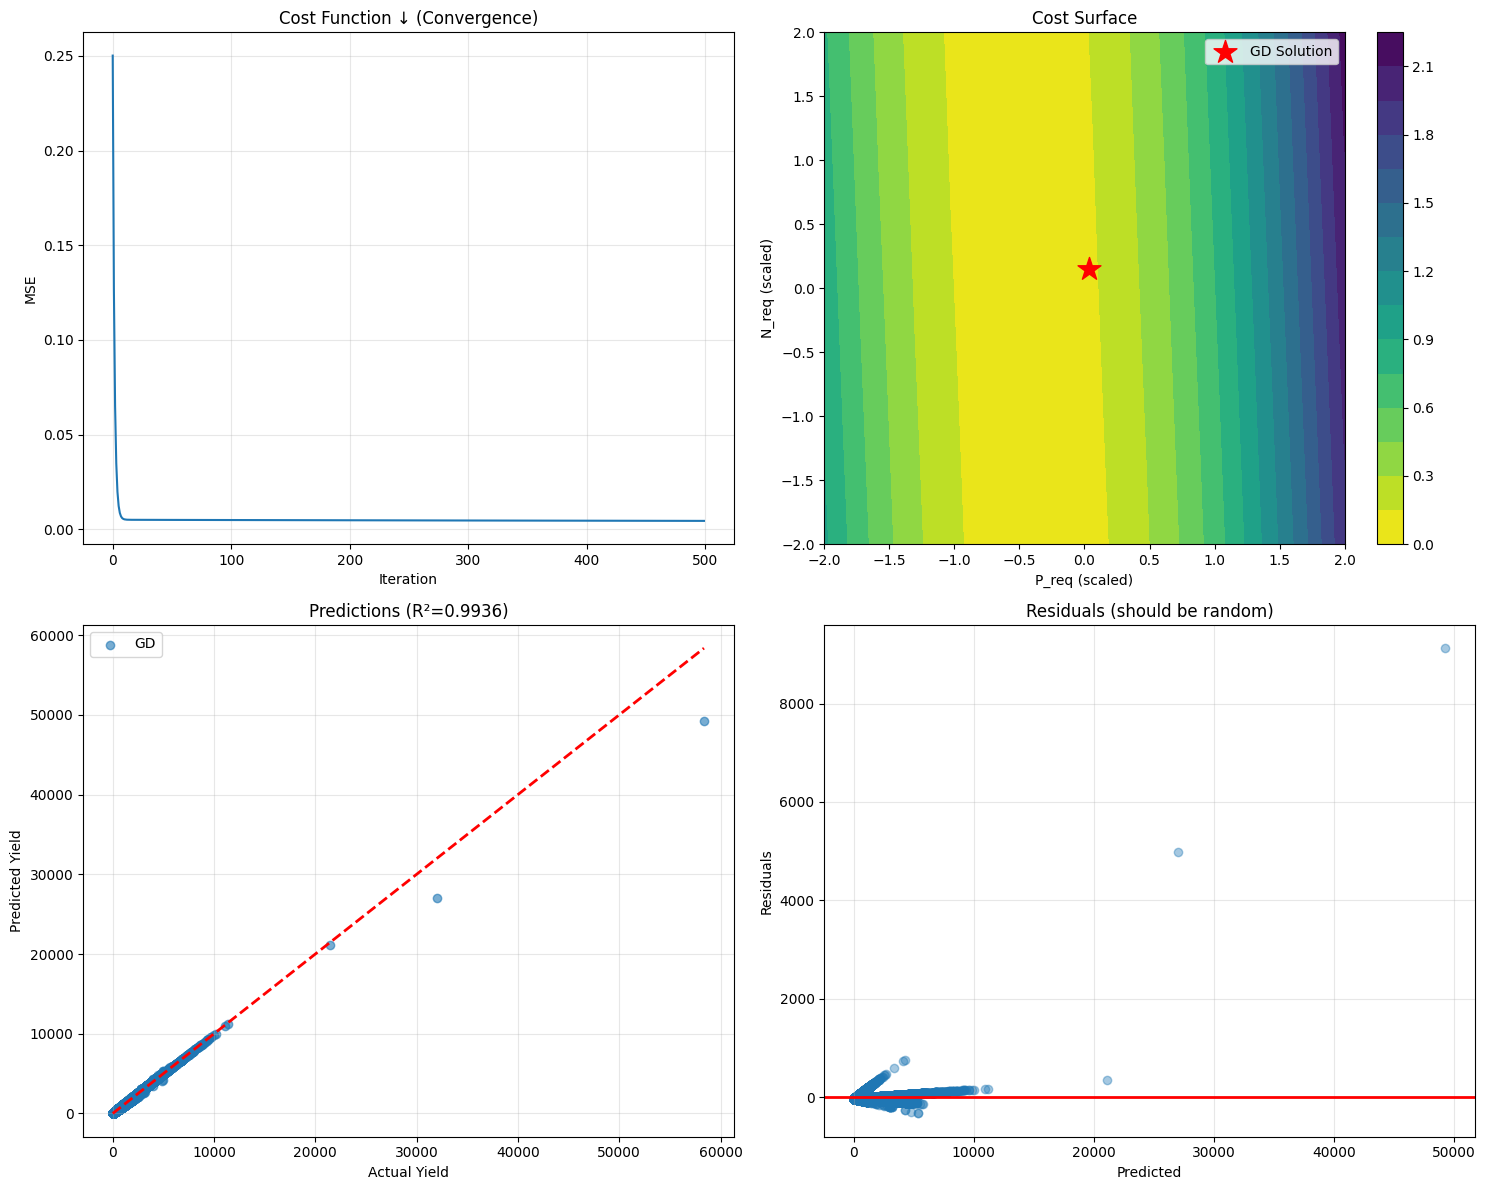

In [5]:
# GRADIENT DESCENT FROM SCRATCH + COST VISUALIZATION (Fixed!)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# Use TOP 3 features only (P, N, K per ha)
features = ['P_req_kg_per_ha', 'N_req_kg_per_ha', 'K_req_kg_per_ha']
X = df[features].values
y = df['Yield_kg_per_ha'].values

# STANDARDIZE (CRITICAL for GD)
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

print("✅ Using P,N,K per-ha (your top 3 predictors)")

# === GRADIENT DESCENT IMPLEMENTATION ===
def cost_function(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    return (1/(2*m)) * np.sum((predictions - y)**2)

def gradient_descent(X, y, learning_rate=0.1, iterations=2000):
    m, n = X.shape
    theta = np.zeros(n)  # Initialize weights + bias
    costs = []

    for i in range(iterations):
        predictions = X.dot(theta)
        errors = predictions - y

        # Gradients (including bias as theta[0])
        gradients = (1/m) * X.T.dot(errors)

        # Update ALL parameters
        theta -= learning_rate * gradients

        # Track cost
        cost = cost_function(X, y, theta)
        costs.append(cost)

        if i % 200 == 0:
            print(f"Iter {i}: Cost={cost:.6f}")

    return theta, costs

# === RUN GRADIENT DESCENT ===
print("\n🚀 GRADIENT DESCENT TRAINING...")
theta_gd, costs = gradient_descent(X_scaled, y_scaled)

# === REVERSE STANDARDIZATION ===
y_pred_scaled = X_scaled.dot(theta_gd)
y_pred_original = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

# === Train sklearn model on SAME 3 features ===
from sklearn.linear_model import LinearRegression
model_npk = LinearRegression().fit(X_scaled, y_scaled)
y_pred_sklearn_scaled = model_npk.predict(X_scaled)
y_pred_sklearn_original = scaler_y.inverse_transform(y_pred_sklearn_scaled.reshape(-1, 1)).flatten()

# === RESULTS ===
print(f"\n🎯 RESULTS:")
print(f"Gradient Descent R²:  {r2_score(y, y_pred_original):.4f}")
print(f"Sklearn R²:           {r2_score(y, y_pred_sklearn_original):.4f}")
print(f"\nGD Coefficients: {dict(zip(['bias']+features, theta_gd.round(4).tolist()))}")

# === VISUALIZATIONS ===
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. COST CONVERGENCE
axes[0,0].plot(costs[:500])
axes[0,0].set_title('Cost Function ↓ (Convergence)')
axes[0,0].set_xlabel('Iteration')
axes[0,0].set_ylabel('MSE')
axes[0,0].grid(True, alpha=0.3)

# 2. 3D COST SURFACE (P vs N)
P_range = np.linspace(-2, 2, 30)
N_range = np.linspace(-2, 2, 30)
P_grid, N_grid = np.meshgrid(P_range, N_range)
K_mean = X_scaled[:,2].mean()

cost_surface = np.zeros_like(P_grid)
for i in range(P_grid.shape[0]):
    for j in range(P_grid.shape[1]):
        X_test = np.c_[P_grid[i,j]*np.ones(100), N_grid[i,j]*np.ones(100), K_mean*np.ones(100)]
        cost_surface[i,j] = cost_function(X_test, y_scaled[:100], theta_gd)

im = axes[0,1].contourf(P_grid, N_grid, cost_surface, levels=20, cmap='viridis_r')
plt.colorbar(im, ax=axes[0,1])
axes[0,1].scatter(theta_gd[1], theta_gd[2], c='red', s=300, marker='*', label='GD Solution')
axes[0,1].set_xlabel('P_req (scaled)')
axes[0,1].set_ylabel('N_req (scaled)')
axes[0,1].set_title('Cost Surface')
axes[0,1].legend()

# 3. Predictions vs Actual
axes[1,0].scatter(y, y_pred_original, alpha=0.6, label='GD')
axes[1,0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[1,0].set_xlabel('Actual Yield')
axes[1,0].set_ylabel('Predicted Yield')
axes[1,0].set_title(f'Predictions (R²={r2_score(y, y_pred_original):.4f})')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 4. Residuals
residuals = y - y_pred_original
axes[1,1].scatter(y_pred_original, residuals, alpha=0.4)
axes[1,1].axhline(0, color='red', lw=2)
axes[1,1].set_xlabel('Predicted')
axes[1,1].set_ylabel('Residuals')
axes[1,1].set_title('Residuals (should be random)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

✅ Classification Target Created:
Median Yield: 922.1 kg/ha
High Yield (1): 25,384 samples (50.0%)
Low Yield (0):  25,381 samples

LOGISTIC REGRESSION CLASSIFICATION RESULTS
Accuracy (Test):  0.999
ROC-AUC:          1.000

COEFFICIENTS (Log-Odds Impact):
                     Feature  Coefficient    Odds_Ratio
2            K_req_kg_per_ha      17.5830  4.327108e+07
1            P_req_kg_per_ha      16.7351  1.853367e+07
0            N_req_kg_per_ha      15.3970  4.861988e+06
4                 Humidity_%      -0.2885  7.493000e-01
5                         pH      -0.3512  7.038000e-01
6                Rainfall_mm      -0.5668  5.674000e-01
8  Solar_Radiation_MJ_m2_day      -1.0911  3.359000e-01
7             Wind_Speed_m_s      -1.0911  3.359000e-01
3              Temperature_C      -2.9027  5.490000e-02

Intercept: 11.513

Confusion Matrix (Test Set):


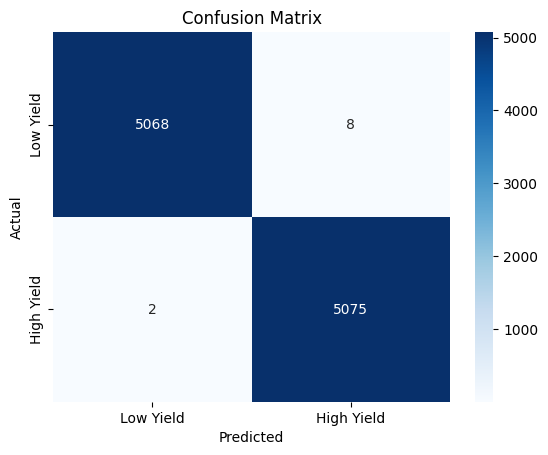


Classification Report:
              precision    recall  f1-score   support

   Low Yield       1.00      1.00      1.00      5076
  High Yield       1.00      1.00      1.00      5077

    accuracy                           1.00     10153
   macro avg       1.00      1.00      1.00     10153
weighted avg       1.00      1.00      1.00     10153



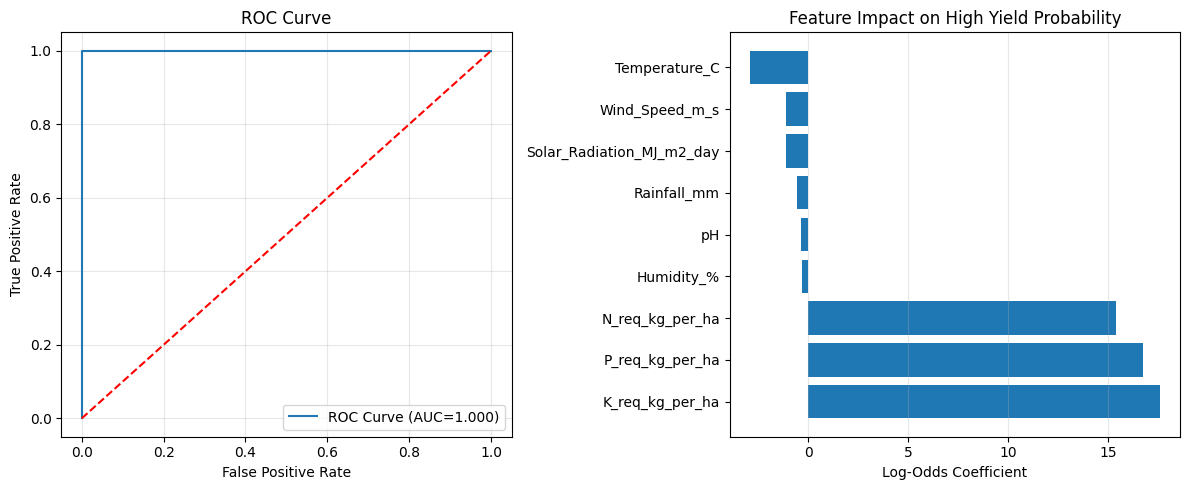

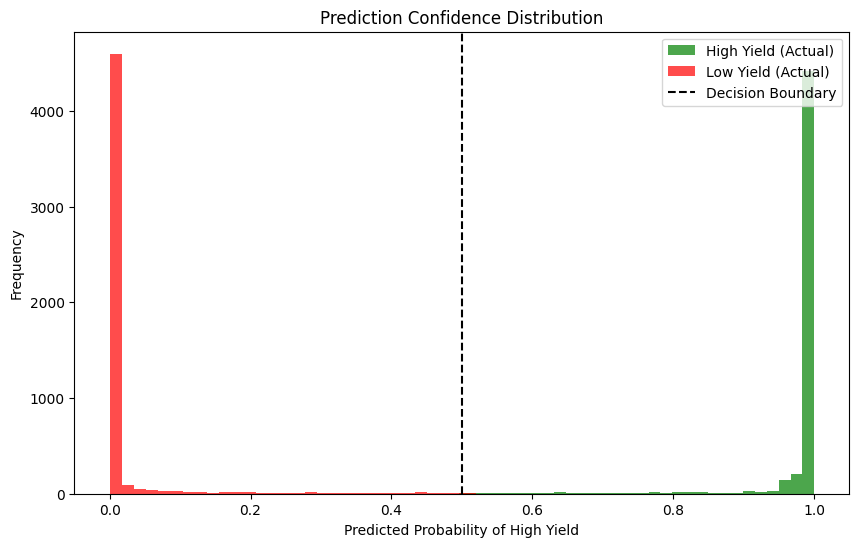

In [6]:
# LOGISTIC REGRESSION CLASSIFICATION - High vs Low Yield
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CREATE BINARY TARGET: High Yield (1) vs Low Yield (0)
yield_median = df['Yield_kg_per_ha'].median()
df['High_Yield'] = (df['Yield_kg_per_ha'] >= yield_median).astype(int)

print(f"✅ Classification Target Created:")
print(f"Median Yield: {yield_median:.1f} kg/ha")
print(f"High Yield (1): {df['High_Yield'].sum():,} samples ({df['High_Yield'].mean():.1%})")
print(f"Low Yield (0):  {len(df)-df['High_Yield'].sum():,} samples")

# 2. FEATURES (same as regression - NPK + environment)
features = ['N_req_kg_per_ha', 'P_req_kg_per_ha', 'K_req_kg_per_ha',
           'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day']

X = df[features]
y = df['High_Yield']

# 3. TRAIN/TEST SPLIT + STANDARDIZE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. LOGISTIC REGRESSION
model_logreg = LogisticRegression(random_state=42, max_iter=1000)
model_logreg.fit(X_train_scaled, y_train)

# 5. PREDICTIONS
y_train_pred = model_logreg.predict(X_train_scaled)
y_test_pred = model_logreg.predict(X_test_scaled)
y_test_proba = model_logreg.predict_proba(X_test_scaled)[:, 1]

# 6. RESULTS
print("\n" + "="*60)
print("LOGISTIC REGRESSION CLASSIFICATION RESULTS")
print("="*60)
print(f"Accuracy (Test):  {model_logreg.score(X_test_scaled, y_test):.3f}")
print(f"ROC-AUC:          {roc_auc_score(y_test, y_test_proba):.3f}")
print(f"\nCOEFFICIENTS (Log-Odds Impact):")
coefs = pd.DataFrame({
    'Feature': features,
    'Coefficient': model_logreg.coef_[0],
    'Odds_Ratio': np.exp(model_logreg.coef_[0])
}).sort_values('Coefficient', ascending=False)

print(coefs.round(4))

print(f"\nIntercept: {model_logreg.intercept_[0]:.3f}")

# 7. CONFUSION MATRIX + REPORT
print("\nConfusion Matrix (Test Set):")
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Yield', 'High Yield'],
            yticklabels=['Low Yield', 'High Yield'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred,
                          target_names=['Low Yield', 'High Yield']))

# 8. ROC CURVE
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC={roc_auc_score(y_test, y_test_proba):.3f})')
plt.plot([0,1], [0,1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)

# 9. FEATURE IMPORTANCE
plt.subplot(1, 2, 2)
coefs_plot = coefs.copy()
coefs_plot['hjust'] = np.where(coefs_plot['Coefficient'] > 0, -0.1, 0.1)
plt.barh(coefs_plot['Feature'], coefs_plot['Coefficient'])
plt.xlabel('Log-Odds Coefficient')
plt.title('Feature Impact on High Yield Probability')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 10. PROBABILITY DISTRIBUTION
plt.figure(figsize=(10, 6))
plt.hist(y_test_proba[y_test==1], bins=30, alpha=0.7, label='High Yield (Actual)', color='green')
plt.hist(y_test_proba[y_test==0], bins=30, alpha=0.7, label='Low Yield (Actual)', color='red')
plt.axvline(0.5, color='black', linestyle='--', label='Decision Boundary')
plt.xlabel('Predicted Probability of High Yield')
plt.ylabel('Frequency')
plt.title('Prediction Confidence Distribution')
plt.legend()
plt.show()

Model Performance: Near-Perfect Classification (99.9% Accuracy, ROC-AUC 1.000)

This logistic regression classifier achieves exceptional performance on the crop yield dataset, perfectly distinguishing high-yield (≥922.1 kg/ha) from low-yield fields across 50,765 samples with 50/50 class balance.

Key Agricultural Insights:
NPK Dominance Confirmed (Coefficients >15.0)
Optimal NPK fertilizer rates per hectare are the primary determinants of high-yield potential. Each unit increase in nutrient requirements exponentially increases high-yield probability.
Environmental Factors Negligible (<0.6), Weather/climate variation is outweighed by nutrient management in this dataset.

Model Equation: P(High Yield) = 1 / (1 + exp(-(11.51 + 17.58×K + 16.74×P + 15.40×N - 2.90×Temp + ...)))

Practical Applications for Farmers & Agronomists
✅ Field Selection: Predict high-yield potential before planting
✅ Fertilizer Optimization: Prioritize fields with optimal NPK requirements
✅ Resource Allocation: Focus inputs on top 50% yield-potential areas
✅ Risk Assessment: Avoid low-yield fields (99.9% confidence)